# 05 — Customer Analysis
**Phase 5 — Brazilian E-Commerce Analytics (Olist)**

Business questions answered:
- How do customers segment by Recency, Frequency, and Monetary value (RFM)?
- How many customers fall into each segment (Champions, Loyal, At Risk, Lost)?
- Which segments have the highest average spend?

In [7]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import get_engine

engine = get_engine()
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [8]:
query = """
    SELECT
        c.customer_unique_id,
        MAX(o.order_purchase_timestamp)          AS last_purchase,
        COUNT(DISTINCT o.order_id)               AS frequency,
        ROUND(SUM(op.payment_value)::numeric, 2) AS monetary
    FROM customers_clean c
    JOIN orders_clean o    ON c.customer_id = o.customer_id
    JOIN order_payments op ON o.order_id = op.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
"""

rfm = pd.read_sql(query, engine)
rfm["last_purchase"] = pd.to_datetime(rfm["last_purchase"])

# Calculate recency in days from last order date in dataset
max_date = rfm["last_purchase"].max()
rfm["recency"] = (max_date - rfm["last_purchase"]).dt.days

rfm.head()

,customer_unique_id,last_purchase,frequency,monetary,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,111
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,114
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,536
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,320
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,287


In [9]:
# Lower recency = better, so reverse rank
rfm["r_score"] = pd.qcut(rfm["recency"],  q=4, labels=[4, 3, 2, 1])
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), q=4, labels=[1, 2, 3, 4])
rfm["m_score"] = pd.qcut(rfm["monetary"],  q=4, labels=[1, 2, 3, 4])

rfm["rfm_score"] = (
    rfm["r_score"].astype(str) +
    rfm["f_score"].astype(str) +
    rfm["m_score"].astype(str)
)

rfm.head()

,customer_unique_id,last_purchase,frequency,monetary,recency,r_score,f_score,m_score,rfm_score
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,111,4,1,3,413
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,114,3,1,1,311
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,536,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,320,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,287,2,1,4,214


In [10]:
def segment(row):
    r = int(row["r_score"])
    f = int(row["f_score"])
    m = int(row["m_score"])

    if r >= 4 and f >= 4:
        return "Champion"
    elif r >= 3 and f >= 3:
        return "Loyal"
    elif r >= 3 and f <= 2:
        return "Potential Loyal"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r == 1 and f == 1:
        return "Lost"
    else:
        return "Needs Attention"

rfm["segment"] = rfm.apply(segment, axis=1)
rfm["segment"].value_counts()

segment
Potential Loyal    23356
At Risk            23187
Loyal              17553
Needs Attention    17423
Champion            5938
Lost                5900
Name: count, dtype: int64

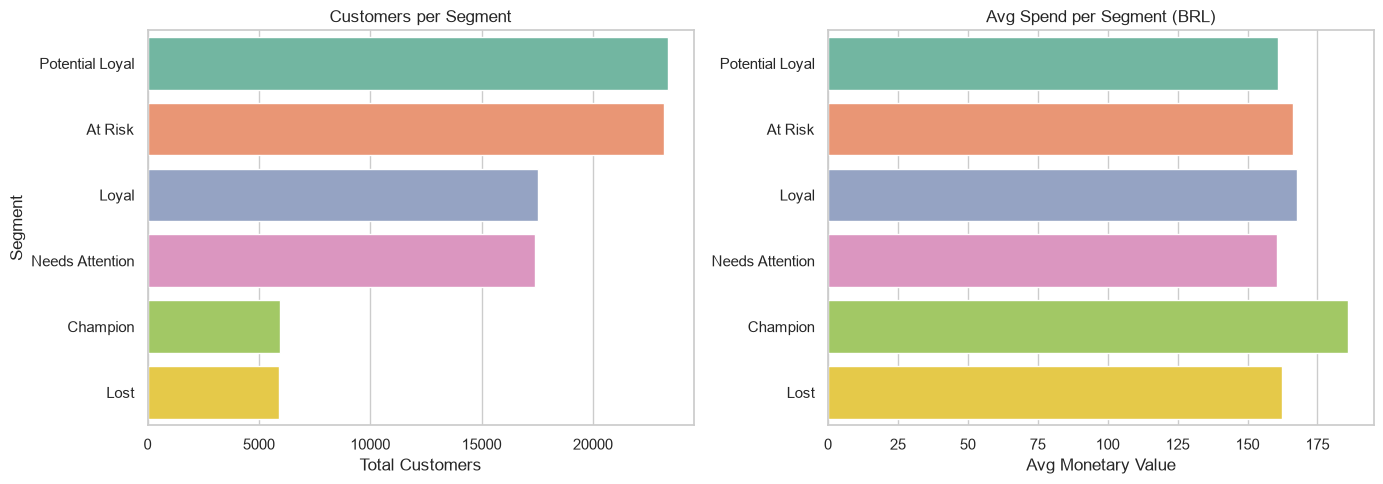

In [11]:
segment_summary = rfm.groupby("segment").agg(
    total_customers=("customer_unique_id", "count"),
    avg_monetary=("monetary", "mean"),
    avg_recency=("recency", "mean")
).reset_index().sort_values("total_customers", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Customer count per segment
sns.barplot(
    data=segment_summary, x="total_customers", y="segment",
    hue="segment", palette="Set2", legend=False, ax=axes[0]
)
axes[0].set_title("Customers per Segment")
axes[0].set_xlabel("Total Customers")
axes[0].set_ylabel("Segment")

# Avg spend per segment
sns.barplot(
    data=segment_summary, x="avg_monetary", y="segment",
    hue="segment", palette="Set2", legend=False, ax=axes[1]
)
axes[1].set_title("Avg Spend per Segment (BRL)")
axes[1].set_xlabel("Avg Monetary Value")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [12]:
print("📊 RFM Segment Summary\n")
print(segment_summary.to_string(index=False))

print(f"\n🏆 Champions: {len(rfm[rfm['segment'] == 'Champion'])} customers")
print(f"⚠️  At Risk:   {len(rfm[rfm['segment'] == 'At Risk'])} customers")
print(f"💀 Lost:       {len(rfm[rfm['segment'] == 'Lost'])} customers")

📊 RFM Segment Summary

        segment  total_customers  avg_monetary  avg_recency
Potential Loyal            23356    160.983326   111.052663
        At Risk            23187    166.414302   363.110105
          Loyal            17553    167.857557   129.827038
Needs Attention            17423    160.500332   334.627906
       Champion             5938    185.920128    56.334456
           Lost             5900    162.219000   451.343559

🏆 Champions: 5938 customers
⚠️  At Risk:   23187 customers
💀 Lost:       5900 customers
